# Reservoir vs active weight tracking — snapshot analysis

Experimental analysis of the dynamically changing **active / reservoir / dormant** weight sets during SoftStairs QAT, driven entirely by saved snapshots (no training happens here):

- `ps` — `[n_snapshots, *weight_shape]` weight snapshots in quantization code space,
- `gs` — matching QAT gradients, already gated by the SoftStairs derivative (`g = H * D`),
- `P` — number of consecutive snapshots taken at the start of each epoch,
  i.e. `start of epoch -> P snapshots -> training -> one t-scheduler step -> start of epoch -> ...`.

Everything below uses the read-only entities from `softstairs_qat.analysis`:

| entity | role |
|---|---|
| `track_sequence` | vectorized EMA scores + ranked three-set classification + transition records |
| `ScoreSeries` (`compute_score_series`) | `EMA(|g|)` pressure, signed EMA, consistency, motion, activity |
| `classify_series`, `labels_from_masks`, `transition_matrices`, `jaccard` | set algebra and churn |
| `summarize`, `records_to_history` | compact per-update statistics |
| `ParameterSetTracker` | streaming variant + masks mapped back to the weight shape |
| `t_schedule_for_snapshots` | per-snapshot temperature respecting the once-per-epoch `t` step |

The key diagnostic is repeated `reservoir -> active -> reservoir` churn rather than permanently active weights — see the last section.

In [1]:
import os

if os.path.basename(os.getcwd()) == "CV":
    os.chdir("../..")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from softstairs_qat.analysis import (
    ParameterSetTracker,
    ScoreConfig,
    SetConfig,
    TrackerConfig,
    classify_series,
    labels_from_masks,
    records_to_history,
    summarize,
    t_schedule_for_snapshots,
    track_sequence,
    transition_matrices,
)
from softstairs_qat.analysis.reader import load_snapshots, load_t_schedule

plt.rcParams.setdefault("figure.dpi", 110)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


100.0

In [92]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
# Provide the tensors this notebook analyses:
#
#   ps : float tensor [n_snapshots, *weight_shape]  code-space weight snapshots
#   gs : float tensor [n_snapshots, *weight_shape]  QAT gradients  g = H * D
#   P  : int   consecutive snapshots taken at the start of each epoch
#
# Replace this cell with your own loading code, e.g.
#
#   ps, gs, P = my_loader(...)          # your code here
#
# Until then, the fallback loads a saved GradSaver snapshot directory.

SNAPSHOT_DIR = (
    "experiments/CV/logs/InceptionNet_STL10_strcyclic_af1_b8_tstandard_majNone_norm"
    "/version_5/Mixed_6e.branch1x1.conv.weight"
)
RUN_DIR = os.path.dirname(SNAPSHOT_DIR)  # holds hparams.yaml; set to None for a constant t
# PARAM_SCOPE = 'fc.weight'
snap = load_snapshots(SNAPSHOT_DIR)
ps, gs = snap.ps, snap.gs
P = snap.snapshots_per_epoch
PARAM_SCOPE = snap.name

print(snap)

SnapshotSet(name='Mixed_6e.branch1x1.conv.weight', num_snapshots=260, weight_shape=(192, 768, 1, 1), snapshots_per_epoch=20)


In [106]:
# auxilliary: in case of huge tensors to fit into the quantile() func 
FACTOR = 4
slc = slice(None, None, FACTOR)
ps = ps[:, slc]
gs = gs[:, slc]

In [107]:
T = ps.shape[0]
weight_shape = tuple(ps.shape[1:])
N = int(np.prod(weight_shape, dtype=int)) if weight_shape else 1
steps = torch.arange(T)
n_epochs = int((T + P - 1) // P)

print(f"T={T} snapshots | weight shape {weight_shape} | N={N} weights | P={P} | epochs={n_epochs}")

# Temperature per snapshot: t is stepped once per epoch, so snapshot i lives at
# t_schedule[i // P] — exactly what t_schedule_for_snapshots maps.
schedule = None
if RUN_DIR is not None:
    try:
        schedule = load_t_schedule(RUN_DIR)
    except FileNotFoundError:
        schedule = None
if schedule is None:
    schedule = [0.5]
    print("no hparams.yaml found -> using a constant t = 0.5")

t_values = t_schedule_for_snapshots(schedule, T, snapshots_per_epoch=P)
print("t per snapshot (first 6):", [round(v, 4) for v in t_values[:6].tolist()])

T=260 snapshots | weight shape (24, 768, 1, 1) | N=18432 weights | P=20 | epochs=13
t per snapshot (first 6): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [157]:
CFG = TrackerConfig(
    score=ScoreConfig(
        decay_pressure=0.9,     # EMA(|g|) — optimizer-momentum-like persistent pressure
        decay_consistency=0.9,  # EMA(g)   — persistent signed push
        decay_motion=0.9,       # EMA(|dp|) — weight motion
        activity_quantile=0.9,  # robust upper bound of the normalized activity
        pressure_quantile=0.0,  # raise (e.g. 0.3) to prune negligible-pressure weights from the reservoir
        use_sensitivity=True,   # consult SoftStairs.derivative (dSS) — no second approximation
        normalized=True,       # SoftStairs.normalized of the analysed run
        async_t_factor=1.0,     # SoftStairs.async_t_factor of the analysed run
    ),
    sets=SetConfig(
        active_fraction=0.5,     # TopK(S_active) budget
        reservoir_fraction=0.25,  # TopK(S_reservoir among ~active) budget
        active_hysteresis=0.0,    # >0 makes active weights stick to the active set
    ),
    record_distributions=True,
    distribution_quantiles=(0.05, 0.5, 0.95),
)
CFG

TrackerConfig(score=ScoreConfig(decay_pressure=0.9, decay_consistency=0.9, decay_motion=0.9, eps=1e-12, activity_quantile=0.9, activity_eps=1e-12, pressure_quantile=0.0, use_sensitivity=True, normalized=True, async_t_factor=1.0, dtype=torch.float32), sets=SetConfig(active_fraction=0.5, active_k=None, reservoir_fraction=0.25, reservoir_k=None, active_hysteresis=0.0), record_distributions=True, distribution_quantiles=(0.05, 0.5, 0.95), chunk_size=None)

In [158]:
records, series = track_sequence(
    ps,
    gs,
    config=CFG,
    t_values=t_values,          # per-snapshot temperature for dSS
    snapshots_per_epoch=P,      # t is stepped once per epoch
)
print(series, "| active score source:", series.active_score_source)
records[-1]

ScoreSeries(num_snapshots=260, weight_shape=(24, 768, 1, 1), active_score_source='sensitivity') | active score source: sensitivity


TrackerRecord(step=259, num_active=9216, num_reservoir=4608, num_dormant=4608, active_jaccard=0.9389859036398064, reservoir_jaccard=0.6741144414168937)

In [159]:
summary = summarize(records)
pd.Series(summary).round(6)

updates                           260.000000
mean_num_active                  9216.000000
mean_num_reservoir               4608.000000
mean_dormant_fraction               0.250000
mean_reservoir_to_active_rate       0.040119
mean_active_to_reservoir_rate       0.021056
mean_active_jaccard                 0.942541
mean_reservoir_jaccard              0.700489
churn_excess                        0.019063
dtype: float64

In [160]:
history = pd.DataFrame(records_to_history(records))
history["epoch"] = history["step"] // P
print(f"{history.shape[1]} columns")
[c for c in history.columns if c.endswith("_count")][:12]

91 columns


['active_added_count',
 'active_removed_count',
 'active_persistent_count',
 'reservoir_added_count',
 'reservoir_removed_count',
 'reservoir_persistent_count',
 'reservoir_to_active_count',
 'active_to_reservoir_count',
 'reservoir_to_dormant_count',
 'dormant_to_reservoir_count',
 'dormant_to_active_count',
 'active_to_dormant_count']

In [161]:
# [T, ...] masks straight from the score series; flatten once for set algebra.
active_m, reservoir_m, dormant_m = classify_series(series, CFG.sets)
A = active_m.reshape(T, -1)
R = reservoir_m.reshape(T, -1)
D = dormant_m.reshape(T, -1)
labels = labels_from_masks(A, R, D)      # [T, N] in {dormant=0, active=1, reservoir=2}
matrices = transition_matrices(labels)   # [T-1, 3, 3] per-step confusion matrices

assert not (A & R).any() and not (A & D).any() and not (R & D).any()
print("masks:", tuple(A.shape), "| sets are pairwise disjoint: True")

# Streaming cross-check + masks mapped back to the original weight shape.
stream = ParameterSetTracker(
    {"weight": ps[0]},
    config=TrackerConfig(score=CFG.score, sets=CFG.sets),
)
stream_records = stream.update_sequence({"weight": ps}, {"weight": gs}, t_values=t_values)
agree = all(
    (a.num_active, a.num_reservoir, a.num_dormant) == (b.num_active, b.num_reservoir, b.num_dormant)
    for a, b in zip(records, stream_records)
)
print(f"streaming tracker agrees with the offline path: {agree}")
stream.counts()

masks: (260, 18432) | sets are pairwise disjoint: True
streaming tracker agrees with the offline path: True


{'active': {'weight': 9216, '__total__': 9216},
 'reservoir': {'weight': 4608, '__total__': 4608},
 'dormant': {'weight': 4608, '__total__': 4608}}

In [162]:
LABEL_NAMES = ["dormant", "active", "reservoir"]
LABEL_COLORS = ["#c8d0da", "#d95f02", "#1b9e77"]
LABEL_CMAP = ListedColormap(LABEL_COLORS)


def set_epoch_axis(ax, every=1):
    """Relabel the x axis of a step-based plot in epochs."""
    ticks = np.arange(0, T, every * P)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t // P) for t in ticks])
    ax.set_xlabel("epoch")


def frame_histograms(values, bins=64, log=True, clip=(0.001, 0.999)):
    """Per-frame histograms over shared bin edges — vectorized, no time loop.

    Args:
        values: [T, ...] signal.
        bins: Number of bins shared by every frame.
        log: Histogram log10 of the values.
        clip: Quantile range used to place the shared bin edges.

    Returns:
        Counts [T, bins] and the bin edges (in the plotted space).
    """
    flat = values.detach().reshape(values.shape[0], -1).float()
    finite = flat[torch.isfinite(flat)]
    lo, hi = torch.quantile(finite, clip[0]), torch.quantile(finite, clip[1])
    tiny = torch.finfo(flat.dtype).tiny
    if log:
        lo, hi = torch.log10(lo.clamp_min(tiny)), torch.log10(hi.clamp_min(tiny * 10))
        flat = torch.log10(flat.clamp_min(tiny))
    edges = torch.linspace(float(lo), float(hi) + 1e-6, bins + 1, device=flat.device)
    idx = torch.bucketize(flat.reshape(-1), edges[1:-1])
    frame_of = torch.arange(flat.shape[0], device=flat.device).repeat_interleave(flat.shape[1])
    counts = torch.bincount(frame_of * bins + idx, minlength=flat.shape[0] * bins)
    return counts.reshape(flat.shape[0], bins), edges


def heatmap(ax, values, edges, title, ylabel="snapshot"):
    """imshow a [T, bins] count matrix whose x axis is the (log) value axis."""
    ax.imshow(
        torch.log10(values.double() + 1).numpy(),
        aspect="auto",
        origin="lower",
        extent=[float(edges[0]), float(edges[-1]), 0, values.shape[0] - 1],
        cmap="magma",
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)


def distribution_panel(signal, title, log=True):
    """Shared-bin histogram heatmap + per-frame median of one signal."""
    counts, edges = frame_histograms(signal, log=log)
    fig, ax = plt.subplots(figsize=(10, 3.2))
    heatmap(ax, counts, edges, title)
    flat = signal.detach().reshape(signal.shape[0], -1).float()
    median = flat.quantile(0.5, dim=1)
    if log:
        median = torch.log10(median.clamp_min(torch.finfo(flat.dtype).tiny))
    ax.plot(median.numpy(), np.arange(T), color="cyan", lw=1.2, label="median")
    ax.legend(loc="upper right")
    ax.set_xlabel("log10 value" if log else "value")
    fig.tight_layout()
    return ax

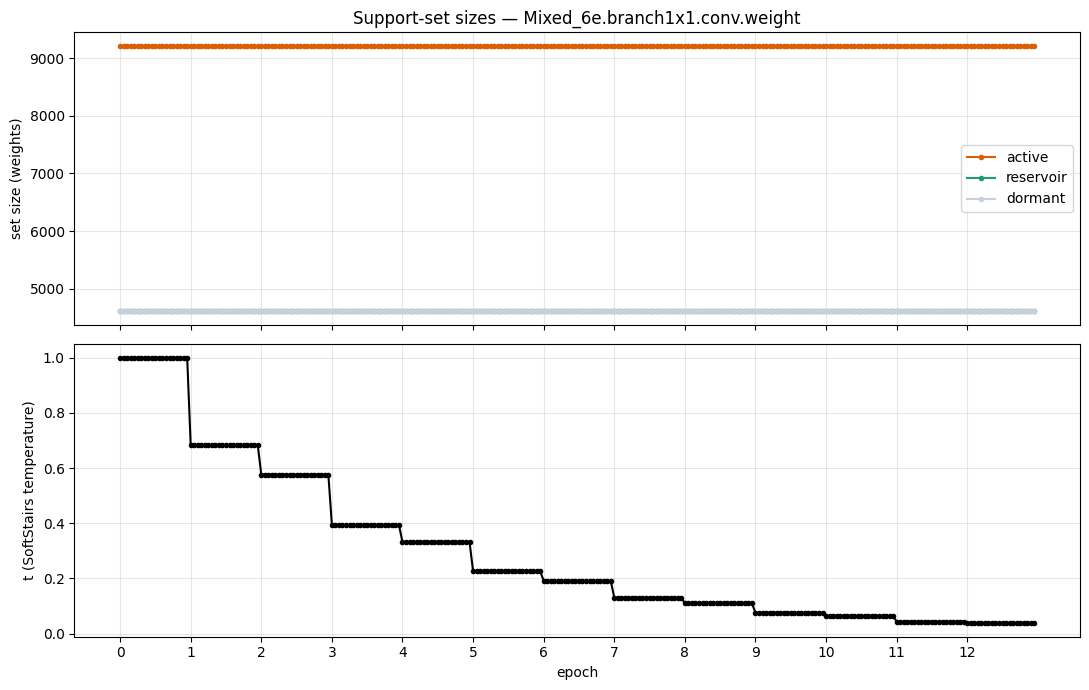

In [163]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.plot(history["step"], history["num_active"], ".-", color=LABEL_COLORS[1], label="active")
ax.plot(history["step"], history["num_reservoir"], ".-", color=LABEL_COLORS[2], label="reservoir")
ax.plot(history["step"], history["num_dormant"], ".-", color=LABEL_COLORS[0], label="dormant")
ax.set_ylabel("set size (weights)")
ax.set_title(f"Support-set sizes — {PARAM_SCOPE}")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(history["step"], t_values.numpy(), ".-", color="k")
ax.set_ylabel("t (SoftStairs temperature)")
ax.grid(alpha=0.3)
set_epoch_axis(ax)
fig.tight_layout()

In [164]:
history[['active_jaccard', 'reservoir_jaccard', 'step']].to_csv()

',active_jaccard,reservoir_jaccard,step\n0,,,0\n1,0.9198000208311634,0.6357827476038339,1\n2,0.9278318167555695,0.6842105263157895,2\n3,0.924812030075188,0.7009966777408638,3\n4,0.9294462472521721,0.7171604248183343,4\n5,0.8945420906567992,0.6407334876268471,5\n6,0.8898800369117195,0.6159915833771699,6\n7,0.8693711967545639,0.5862306368330464,7\n8,0.8836995401124169,0.6366542354821524,8\n9,0.8914315033350436,0.6614386154678205,9\n10,0.9005980614559703,0.6695652173913044,10\n11,0.8794738452126032,0.6225352112676056,11\n12,0.8994229183841714,0.6710788757932911,12\n13,0.8689920908537822,0.6002778260114603,13\n14,0.900990099009901,0.6530941704035874,14\n15,0.9168053244592346,0.7060348019252128,15\n16,0.9005980614559703,0.6407334876268471,16\n17,0.8931799506984388,0.6052952447308831,17\n18,0.8966865610207861,0.6120342837152353,18\n19,0.9220020855057351,0.672898892721002,19\n20,0.9623123602682849,0.8432,20\n21,0.931468091795033,0.759114334796717,21\n22,0.9564802038000212,0.8238670096972096,2

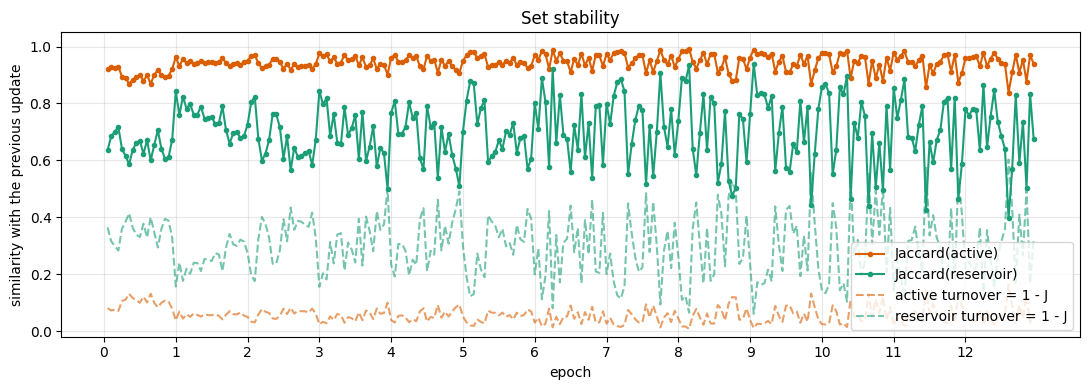

In [165]:
fig, ax = plt.subplots(figsize=(11, 4))
idx = history["step"][1:]
ax.plot(idx, history["active_jaccard"][1:].astype(float), ".-", color=LABEL_COLORS[1],
        label="Jaccard(active)")
ax.plot(idx, history["reservoir_jaccard"][1:].astype(float), ".-", color=LABEL_COLORS[2],
        label="Jaccard(reservoir)")
ax.plot(idx, history["active_turnover"][1:].astype(float), "--", color=LABEL_COLORS[1], alpha=0.6,
        label="active turnover = 1 - J")
ax.plot(idx, history["reservoir_turnover"][1:].astype(float), "--", color=LABEL_COLORS[2], alpha=0.6,
        label="reservoir turnover = 1 - J")
ax.set_ylim(-0.02, 1.05)
ax.set_ylabel("similarity with the previous update")
ax.set_title("Set stability")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
set_epoch_axis(ax)
fig.tight_layout()

In [166]:
history.loc[:, ~(history.nunique(0) == 1)][[f"{name}_source_fraction" for name in CROSS]].tail(10)

,reservoir_to_active_source_fraction,active_to_reservoir_source_fraction,dormant_to_active_source_fraction,active_to_dormant_source_fraction,dormant_to_reservoir_source_fraction,reservoir_to_dormant_source_fraction
250,0.039280,0.022027,0.018446,0.006836,0.143229,0.148003
251,0.045790,0.022461,0.019097,0.009983,0.174262,0.173394
252,0.110677,0.056315,0.065538,0.031793,0.319227,0.321181
253,0.055556,0.033529,0.039931,0.014214,0.208550,0.220052
254,0.020616,0.011502,0.008464,0.003038,0.070964,0.073351
255,0.064887,0.032661,0.031033,0.015299,0.191840,0.192274
256,0.033203,0.016602,0.013889,0.006944,0.119575,0.119575
257,0.082899,0.046658,0.048177,0.018880,0.237630,0.248047
258,0.022352,0.011285,0.007812,0.003798,0.069010,0.069227
259,0.041450,0.022027,0.021484,0.009440,0.150608,0.153212


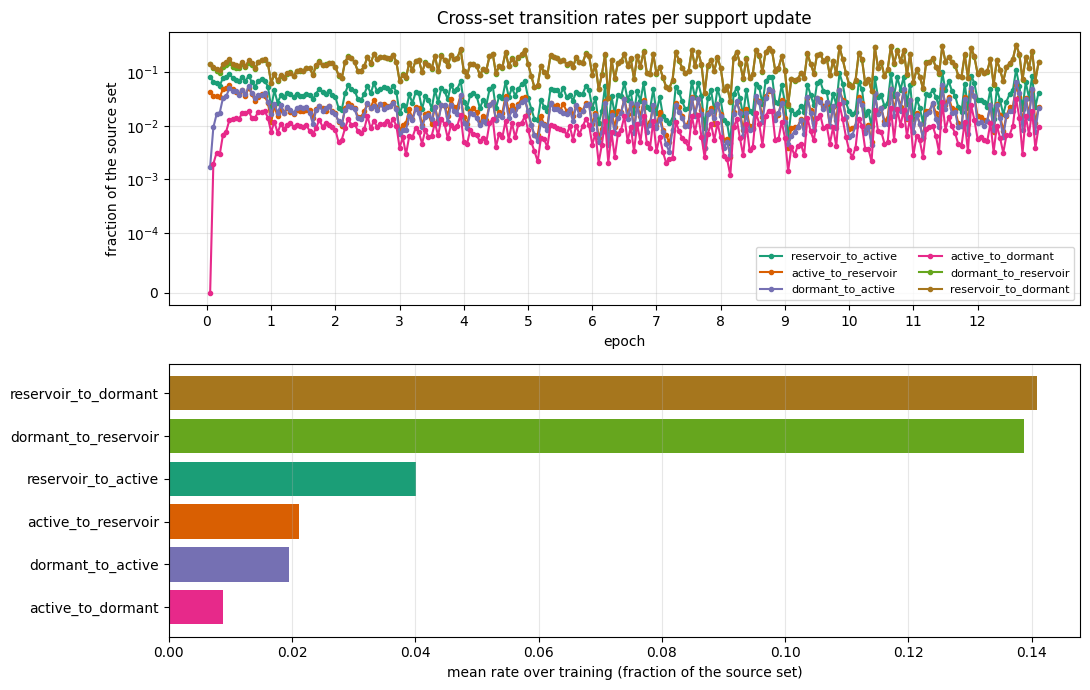

In [167]:
CROSS = [
    "reservoir_to_active",
    "active_to_reservoir",
    "dormant_to_active",
    "active_to_dormant",
    "dormant_to_reservoir",
    "reservoir_to_dormant",
]
COLORS = {
    "reservoir_to_active": "#1b9e77",
    "active_to_reservoir": "#d95f02",
    "dormant_to_active": "#7570b3",
    "active_to_dormant": "#e7298a",
    "dormant_to_reservoir": "#66a61e",
    "reservoir_to_dormant": "#a6761d",
}

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

ax = axes[0]
idx = history["step"][1:]
for name in CROSS:
    ax.plot(idx, history[f"{name}_source_fraction"][1:], ".-", color=COLORS[name], label=name)
ax.set_yscale("symlog", linthresh=1e-4)
ax.set_ylabel("fraction of the source set")
ax.set_title("Cross-set transition rates per support update")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=8)
set_epoch_axis(ax)

ax = axes[1]
means = [float(np.mean(history[f"{name}_source_fraction"][1:])) for name in CROSS]
order = np.argsort(means)
ax.barh([CROSS[i] for i in order], [means[i] for i in order],
        color=[COLORS[CROSS[i]] for i in order])
ax.set_xlabel("mean rate over training (fraction of the source set)")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()

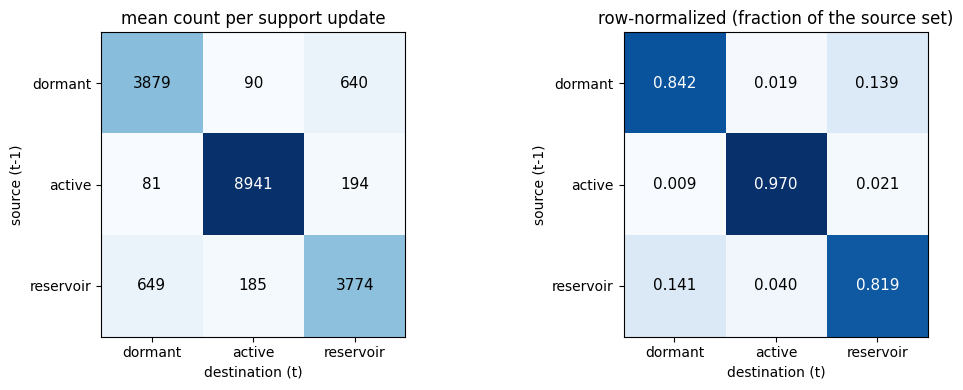

In [168]:
mean_matrix = matrices.float().mean(0)
row_normalized = mean_matrix / mean_matrix.sum(1, keepdim=True).clamp_min(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, fmt in ((axes[0], mean_matrix, "{:.0f}"), (axes[1], row_normalized, "{:.3f}")):
    ax.imshow(mat.numpy(), cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, fmt.format(mat[i, j].item()), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=11)
    ax.set_xticks(range(3), LABEL_NAMES)
    ax.set_yticks(range(3), LABEL_NAMES)
    ax.set_xlabel("destination (t)")
    ax.set_ylabel("source (t-1)")
axes[0].set_title("mean count per support update")
axes[1].set_title("row-normalized (fraction of the source set)")
fig.tight_layout()

<Axes: title={'center': 'EMA(|p_t - p_t-1|) — weight motion'}, xlabel='log10 value', ylabel='snapshot'>

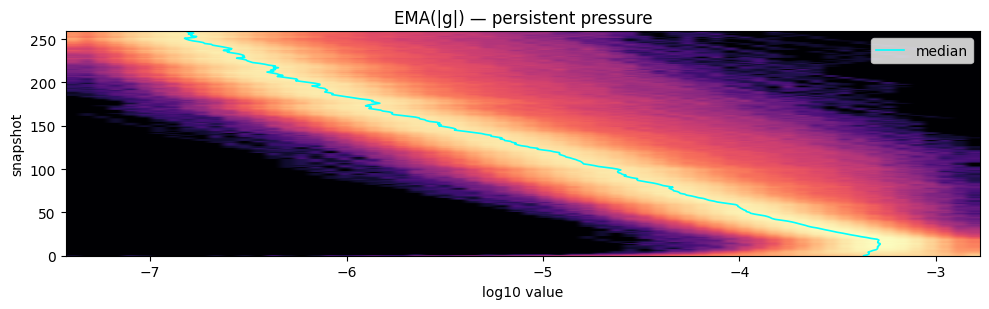

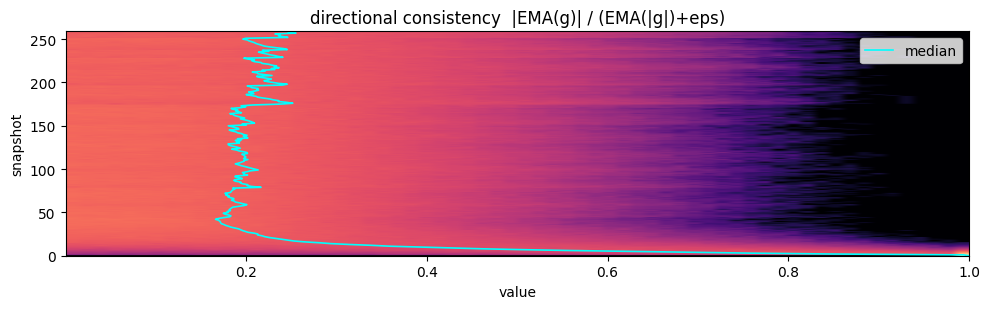

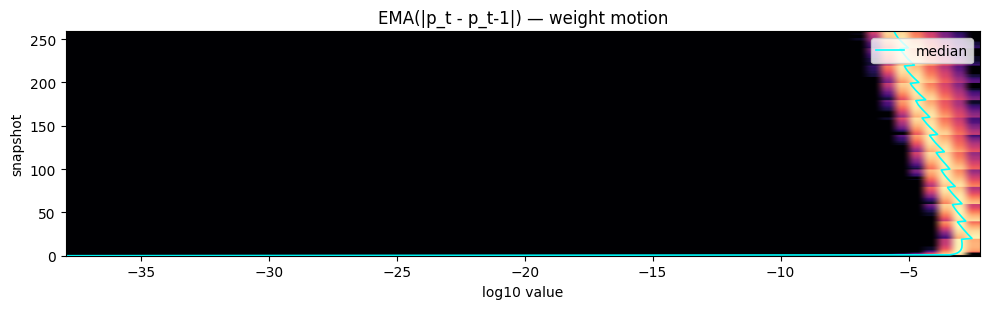

In [169]:
# EMA pressure / consistency / motion distributions across training (§13 item 7).
distribution_panel(series.pressure, "EMA(|g|) — persistent pressure")
distribution_panel(series.consistency, "directional consistency  |EMA(g)| / (EMA(|g|)+eps)", log=False)
distribution_panel(series.motion, "EMA(|p_t - p_t-1|) — weight motion")

<Axes: title={'center': 'normalized activity'}, xlabel='value', ylabel='snapshot'>

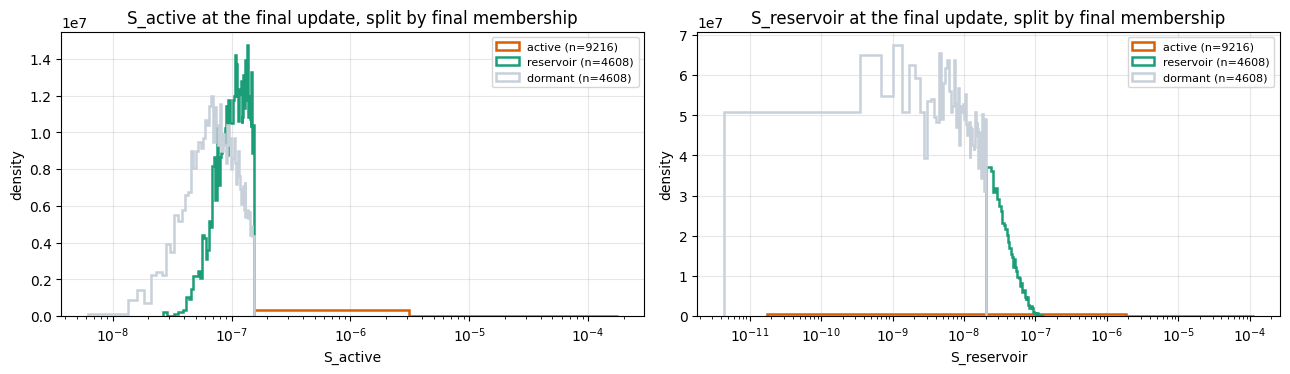

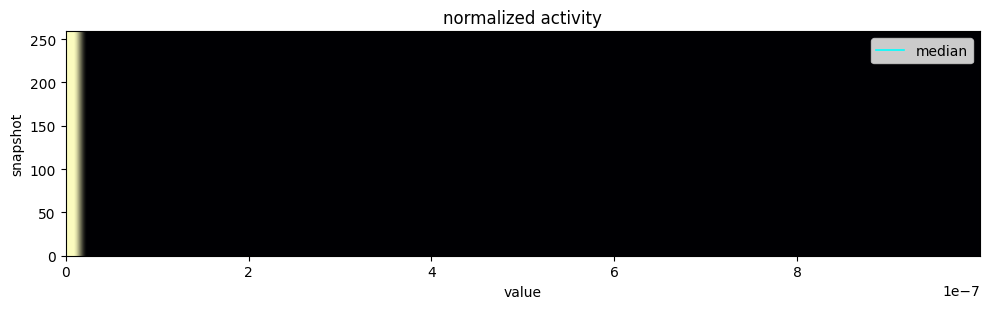

In [170]:
# Active vs reservoir score distributions at the final support update (§13 item 8).
a_last, r_last, d_last = A[-1], R[-1], D[-1]
active_score = series.active_score[-1].reshape(-1)
reservoir_score = series.reservoir_score[-1].reshape(-1)

groups = (
    ("active", a_last, LABEL_COLORS[1]),
    ("reservoir", r_last, LABEL_COLORS[2]),
    ("dormant", d_last, LABEL_COLORS[0]),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, signal, name in ((axes[0], active_score, "S_active"), (axes[1], reservoir_score, "S_reservoir")):
    for label, mask, color in groups:
        values = signal[mask]
        if values.numel():
            ax.hist(values.numpy(), bins=60, histtype="step", lw=1.8, density=True,
                    color=color, label=f"{label} (n={int(values.numel())})")
    ax.set_xscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.set_title(f"{name} at the final update, split by final membership")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()

# Normalized activity over time: (1 - activity) is the factor damping the reservoir score.
distribution_panel(series.activity, "normalized activity", log=False)

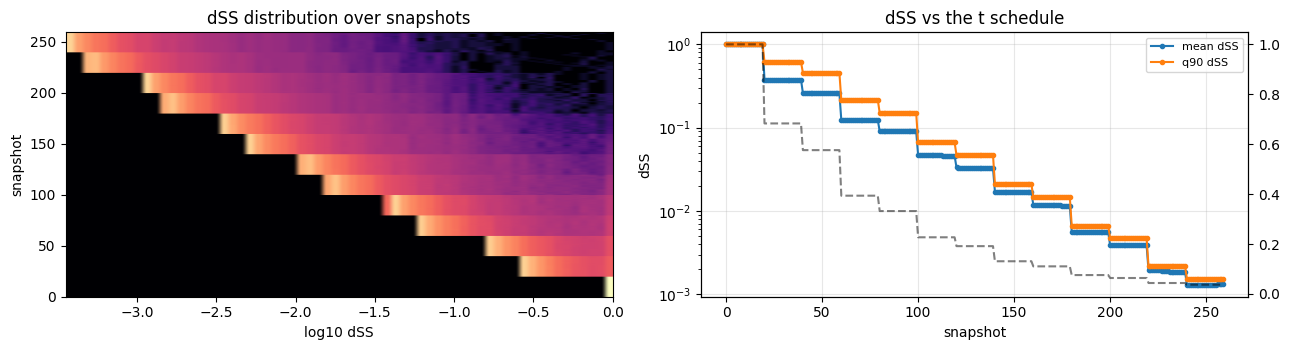

In [171]:
# SoftStairs derivative dSS — recomputed via SoftStairs.derivative, never re-approximated.
if series.sensitivity is not None:
    sensitivity = series.sensitivity.reshape(T, -1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

    counts, edges = frame_histograms(series.sensitivity, log=True)
    heatmap(axes[0], counts, edges, "dSS distribution over snapshots")
    axes[0].set_xlabel("log10 dSS")

    axes[1].plot(history["step"], sensitivity.mean(1), ".-", label="mean dSS")
    axes[1].plot(history["step"], sensitivity.quantile(0.9, dim=1), ".-", label="q90 dSS")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("snapshot")
    axes[1].set_ylabel("dSS")
    axes[1].set_title("dSS vs the t schedule")
    axes[1].twinx().plot(history["step"], t_values.numpy(), "k--", alpha=0.5)
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=8)
    fig.tight_layout()
else:
    print("sensitivity unavailable (use_sensitivity=False or no t) — scored purely from |g|")

weights entering the active set at least once    : 13833 / 18432
weights with a reservoir->active->reservoir cycle: 11359 / 18432
mean active spells per weight                    : 3.859
mean share of updates spent active               : 0.500


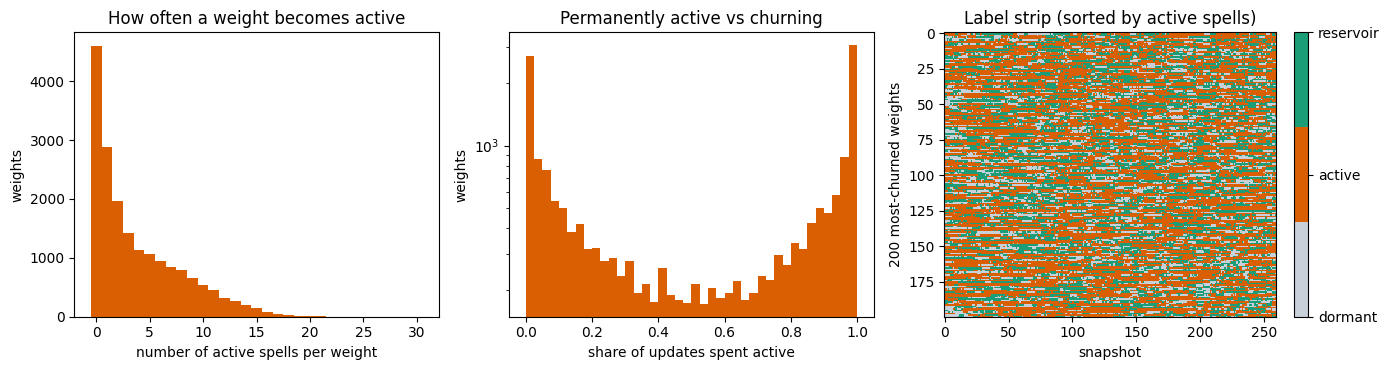

In [172]:
# The key diagnostic: repeated reservoir -> active -> reservoir churn (§13).
enter_active = A[1:] & ~A[:-1]           # any set -> active
res_to_act = R[:-1] & A[1:]
act_to_res = A[:-1] & R[1:]

spells = enter_active.sum(0)             # active spells per weight
time_active = A.float().mean(0)          # share of updates spent active
cycled = res_to_act.any(0) & act_to_res.any(0)

print(f"weights entering the active set at least once    : {int((spells > 0).sum())} / {N}")
print(f"weights with a reservoir->active->reservoir cycle: {int(cycled.sum())} / {N}")
print(f"mean active spells per weight                    : {spells.float().mean():.3f}")
print(f"mean share of updates spent active               : {time_active.mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(spells.numpy(), bins=np.arange(-0.5, float(spells.max()) + 1.5, 1.0),
             color=LABEL_COLORS[1])
axes[0].set_xlabel("number of active spells per weight")
axes[0].set_ylabel("weights")
axes[0].set_title("How often a weight becomes active")

axes[1].hist(time_active.numpy(), bins=40, color=LABEL_COLORS[1])
axes[1].set_yscale("log")
axes[1].set_xlabel("share of updates spent active")
axes[1].set_ylabel("weights")
axes[1].set_title("Permanently active vs churning")

order = spells.argsort(descending=True)[: min(200, N)]
image = axes[2].imshow(
    labels[:, order].T.numpy(), aspect="auto", interpolation="nearest",
    cmap=LABEL_CMAP, vmin=0, vmax=2,
)
axes[2].set_xlabel("snapshot")
axes[2].set_ylabel(f"{order.numel()} most-churned weights")
axes[2].set_title("Label strip (sorted by active spells)")
colorbar = fig.colorbar(image, ax=axes[2], ticks=[0, 1, 2], fraction=0.04)
colorbar.ax.set_yticklabels(LABEL_NAMES)
fig.tight_layout()

In [184]:
torch.quantile(time_active.float(), torch.linspace(0, 100, 11) / 100 )

tensor([0.0000, 0.0038, 0.0500, 0.1308, 0.2731, 0.4923, 0.7231, 0.8731, 0.9577,
        1.0000, 1.0000])

## How to read this

- **Set sizes** — with fixed budgets the sizes are constant by construction; the interesting signal is in the *composition changes* below.
- **Stability** — a falling `Jaccard(active)` together with a rising `reservoir_to_active` rate is exactly the `reservoir -> active -> reservoir` churn this tracker is built to expose.
- **Transition rates** — `reservoir_to_active` measures promotion out of the standing-by pool; `active_to_reservoir` measures demotion back into it. Their balance (`churn_excess` in the summary) says whether sensitivity sweeps across the network or burns out.
- **Label strip** — a row that repeatedly lights up orange (active) and green (reservoir) at different snapshots is a repeated transition, exactly what the hypothesis predicts; a uniformly orange row would instead mean a permanently active weight.
- **Pressure / consistency / motion panels** — persistent pressure that builds up *before* a weight is promoted is the EMA behaviour required by the design: a single gradient spike must not redefine the reservoir, a persistent gradient must eventually promote it.

Optional export (uncomment to write results next to the snapshot run):

```python
# out_dir = os.path.join(RUN_DIR, PARAM_SCOPE)
# os.makedirs(out_dir, exist_ok=True)
# history.to_csv(os.path.join(out_dir, "set_tracking_history.csv"), index=False)
# with open(os.path.join(out_dir, "set_tracking_summary.json"), "w") as handle:
#     import json
#     json.dump({k: float(v) for k, v in summarize(records).items()}, handle, indent=2)
```